In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import psutil
import time
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.impute import SimpleImputer

In [6]:
def get_usage():
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / (1024 ** 2) # MB
    cpu_time = process.cpu_times().user + process.cpu_times().system
    return mem, cpu_time

start_mem, start_cpu = get_usage()
start_wall = time.time()

In [7]:
DATA_DIR = "../../data/raw/final_dataset.csv"

# Adjust to not use much memory
CHUNK_SIZE = 10_000
MAX_LABEL = 200_000

counts = {}
parts = []

for chunk in pd.read_csv(DATA_DIR, chunksize=CHUNK_SIZE):
    for label, group in chunk.groupby("Label"):
        n = counts.get(label, 0)
        if n >= MAX_LABEL:
            continue

        group_shuffled = group.sample(frac=1, random_state=1)
        take = group_shuffled.iloc[: MAX_LABEL - n]
        parts.append(take)
        counts[label] = n + len(take)

    if len(counts) == 2 and all(c >= MAX_LABEL for c in counts.values()):
        break

df = pd.concat(parts, ignore_index=True)
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
print(df["Label"].value_counts())

Label
ddos      200000
Benign    200000
Name: count, dtype: int64


In [8]:
"""
Feature engineering:
    Drop non-numeric or irrelevant columns.
    Random Forest handles non-linearity well, but still needs numeric input.
    One-hot encode Protocol as it's categorical.
"""

df_features = df.copy()

columns_to_drop = [
    "Label",
    "Unnamed: 0",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp",
    "Src Port",
    "Dst Port",
]
df_features = df_features.drop(columns=columns_to_drop)

df_features = pd.get_dummies(df_features, columns=["Protocol"], prefix="Protocol")

X = df_features.values
y = df["Label"].values

y_numeric = np.where(y == "ddos", 1, 0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label vector shape: {y_numeric.shape}")
print(f"Number of features: {X.shape[1]}")


Feature matrix shape: (400000, 79)
Label vector shape: (400000,)
Number of features: 79


In [9]:
"""
Cleaning:
   There were some issues with inf being present, so we replace those with NaN.
   Then we replace NaN with column median. Median is better than mean wrt outliers.
"""

X = X.astype(np.float64)
X = np.where(np.isinf(X), np.nan, X)

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

In [10]:
"""
Splitting data:
  - 60% training
  - 20% validation (we'll tune hyperparameters here)
  - 20% test
"""

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_numeric,
    test_size=0.2,
    random_state=1,
    stratify=y_numeric,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [11]:
"""
Hyperparameter tuning:
    We tune n_estimators (number of trees) and max_depth.
    More trees generally helps until accuracy plateaus, after which it's just wasted compute.
    Max depth controls overfitting: unlimited depth can overfit, too shallow can underfit.
    Note: Random Forest doesn't need feature scaling unlike kNN.
"""

n_estimators_values = [10, 25, 50, 75, 100, 150, 200]
val_accuracies = []
train_accuracies = []

for n in n_estimators_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, rf.predict(X_train))
    train_accuracies.append(train_acc)

    val_acc = accuracy_score(y_val, rf.predict(X_val))
    val_accuracies.append(val_acc)

best_n_idx = np.argmax(val_accuracies)
best_n = n_estimators_values[best_n_idx]
best_val_acc = val_accuracies[best_n_idx]
print(f"Best n_estimators: {best_n}, Validation Accuracy: {best_val_acc:.4f}")

Best n_estimators: 200, Validation Accuracy: 0.9992


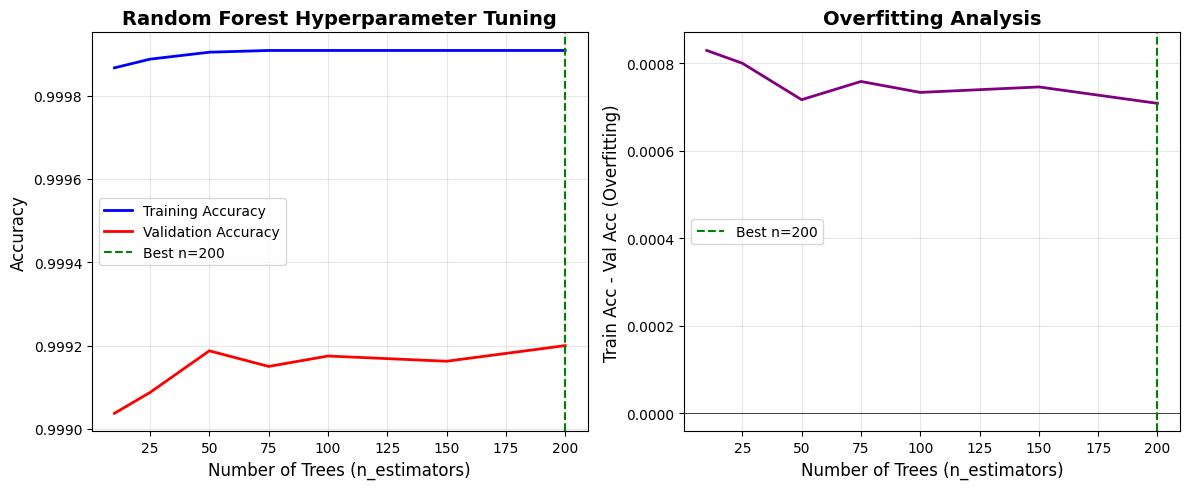

In [12]:
"""
Visualising:
    Accuracy versus n_estimators to see where it plateaus and if there's overfitting.
"""

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_estimators_values, train_accuracies, "b-", label="Training Accuracy", linewidth=2)
plt.plot(n_estimators_values, val_accuracies, "r-", label="Validation Accuracy", linewidth=2)
plt.axvline(x=best_n, color="g", linestyle="--", label=f"Best n={best_n}")
plt.xlabel("Number of Trees (n_estimators)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Random Forest Hyperparameter Tuning", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
overfit_gap = np.array(train_accuracies) - np.array(val_accuracies)
plt.plot(n_estimators_values, overfit_gap, "purple", linewidth=2)
plt.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
plt.axvline(x=best_n, color="g", linestyle="--", label=f"Best n={best_n}")
plt.xlabel("Number of Trees (n_estimators)", fontsize=12)
plt.ylabel("Train Acc - Val Acc (Overfitting)", fontsize=12)
plt.title("Overfitting Analysis", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../plots/rf_hyperparameter_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
"""
Training:
    Use best_n found during hyperparameter tuning.
"""

final_rf = RandomForestClassifier(n_estimators=best_n, random_state=1, n_jobs=-1)
final_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
"""
Evaluate on test data:
    We do this only once!!!
"""

y_test_pred = final_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test, y_test_pred, target_names=["Benign", "DDoS"], digits=4
    )
)


Test Accuracy: 0.9992

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9995    0.9988    0.9992     40000
        DDoS     0.9988    0.9995    0.9992     40000

    accuracy                         0.9992     80000
   macro avg     0.9992    0.9992    0.9992     80000
weighted avg     0.9992    0.9992    0.9992     80000



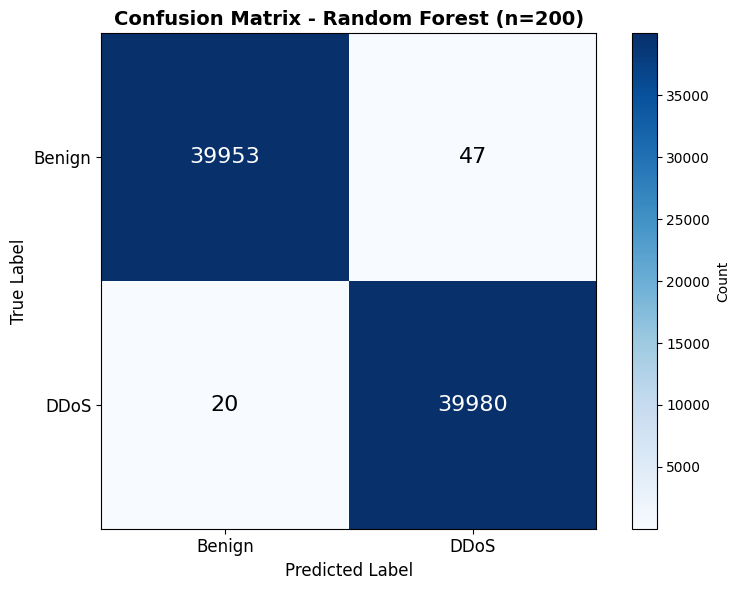

In [15]:
"""
Confusion matrix:
    We can use this to then make a ROC and AUC to see TPR/FPR and performance
"""

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix - Random Forest (n={best_n})", fontsize=14, fontweight="bold")
plt.colorbar(label="Count")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=16,
        )

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Benign", "DDoS"], fontsize=12)
plt.yticks(tick_marks, ["Benign", "DDoS"], fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("../../plots/rf_confusion_matrix.png", dpi=300, bbox_inches="tight")


ROC AUC Score: 1.0000


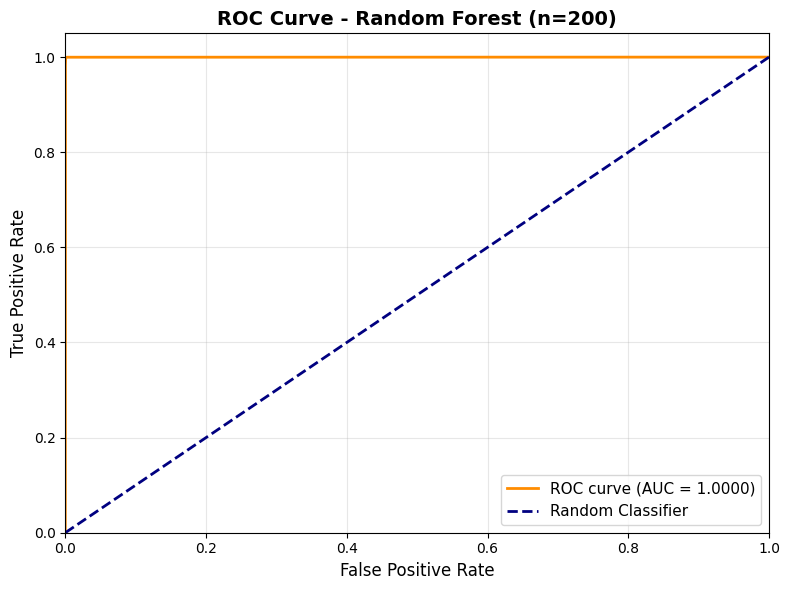

In [16]:
"""
ROC and AUC:
    ROC shows tradeoff between TPR and FPR.
    AUC shows overall performance, with 1 perfect and 0.5 random.
    NOTE: something to talk about in report is how much we actually care about TPR and FPR.
"""

y_test_proba = final_rf.predict_proba(X_test)[:, 1]  # prob of ddos (label 1)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr, color="darkorange", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})"
)
plt.plot(
    [0, 1], [0, 1], color="navy", linewidth=2, linestyle="--", label="Random Classifier"
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title(f"ROC Curve - Random Forest (n={best_n})", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../plots/rf_roc_curve.png", dpi=300, bbox_inches="tight")

print(f"\nROC AUC Score: {roc_auc:.4f}")

In [17]:
"""
Cross validation:
    We do 5-fold CV on combined train+validation data.
    We're already done with hyperparameters so more data = good.
"""

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

cv_scores = cross_val_score(final_rf, X_trainval, y_trainval, cv=5, scoring="accuracy")

print(f"Scores per fold: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Scores per fold: [0.99910937 0.9991875  0.999125   0.9990625  0.99907813]
Mean CV Accuracy: 0.9991 (+/- 0.0000)


Top 20 Most Important Features:
1. Fwd Seg Size Min: 0.1862
2. Init Fwd Win Byts: 0.0988
3. Init Bwd Win Byts: 0.0791
4. SYN Flag Cnt: 0.0482
5. Bwd Header Len: 0.0475
6. PSH Flag Cnt: 0.0425
7. Protocol_6: 0.0352
8. Fwd Header Len: 0.0298
9. Bwd Pkt Len Min: 0.0223
10. Tot Bwd Pkts: 0.0169
11. Bwd Pkts/s: 0.0163
12. Fwd Pkt Len Min: 0.0162
13. Fwd Pkts/s: 0.0154
14. Subflow Bwd Pkts: 0.0151
15. Tot Fwd Pkts: 0.0146
16. Protocol_17: 0.0137
17. Flow Duration: 0.0125
18. Down/Up Ratio: 0.0124
19. Pkt Len Min: 0.0123
20. Flow Byts/s: 0.0122


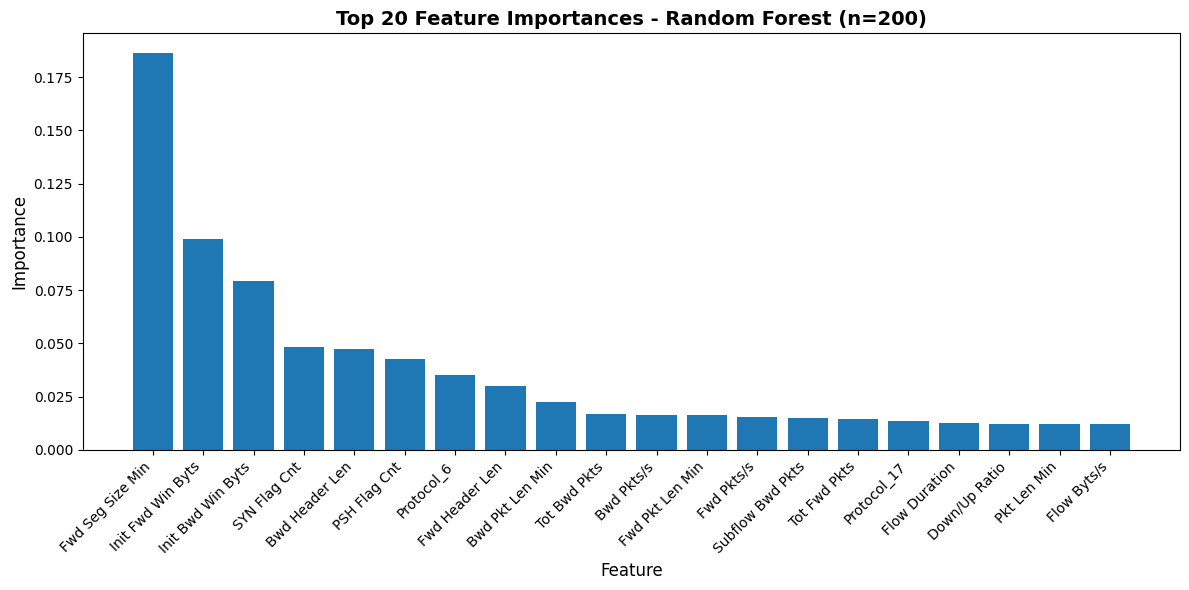

In [18]:
"""
Feature importance:
    Random Forest tracks how much each feature reduces impurity across all trees.
    Higher = more important for distinguishing Benign vs DDoS.
"""

feature_names = df_features.columns.tolist()
importances = final_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Print top 20
print("Top 20 Most Important Features:")
for i in range(20):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Plot top 20
plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=45, ha="right")
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.title(f"Top 20 Feature Importances - Random Forest (n={best_n})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../plots/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
print(f"Dataset Size: {len(X)} samples")
print(f"Features: {X.shape[1]}")
print(f"Classes: Benign (0), DDoS (1)")
print(f"\nBest n_estimators: {best_n}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"CV Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

plt.show()

Dataset Size: 400000 samples
Features: 79
Classes: Benign (0), DDoS (1)

Best n_estimators: 200
Validation Accuracy: 0.9992
Test Accuracy: 0.9992
ROC AUC: 1.0000
CV Mean Accuracy: 0.9991 (+/- 0.0000)


In [20]:
"""
Save plot data to CSV so plots can be reproduced without re-running the model, and so we can compare.
"""

pd.DataFrame({
    "n_estimators": n_estimators_values,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies,
    "overfit_gap": np.array(train_accuracies) - np.array(val_accuracies)
}).to_csv("../../data/rf_overfit_gap.csv", index=False)

pd.DataFrame(
    cm,
    index=["True_Benign", "True_DDoS"],
    columns=["Pred_Benign", "Pred_DDoS"]
).to_csv("../../data/rf_confusion_matrix.csv")

pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds
}).to_csv("../../data/rf_roc_curve.csv", index=False)


In [21]:
"""
Save resource usage:
    Appends RAM usage, CPU time, and wall time (MB, sec) to csv.
"""

end_wall = time.time()
end_mem, end_cpu = get_usage()

usage_df = pd.DataFrame([{
    "model": "RF",
    "ram_delta_mb": end_mem - start_mem,
    "cpu_time_sec": end_cpu - start_cpu,
    "wall_time_sec": end_wall - start_wall
}])

usage_file = "../../data/resource_usage.csv"
usage_df.to_csv(usage_file, mode='a', header=not os.path.exists(usage_file), index=False)

In [23]:
"""
Save model:
    Saves a pkl file of the trained model.
"""
os.makedirs("../../data/models", exist_ok=True)
joblib.dump(final_rf, "../../data/models/rf_model.pkl")
joblib.dump(imputer, "../../data/models/rf_imputer.pkl")

['../../data/models/rf_imputer.pkl']

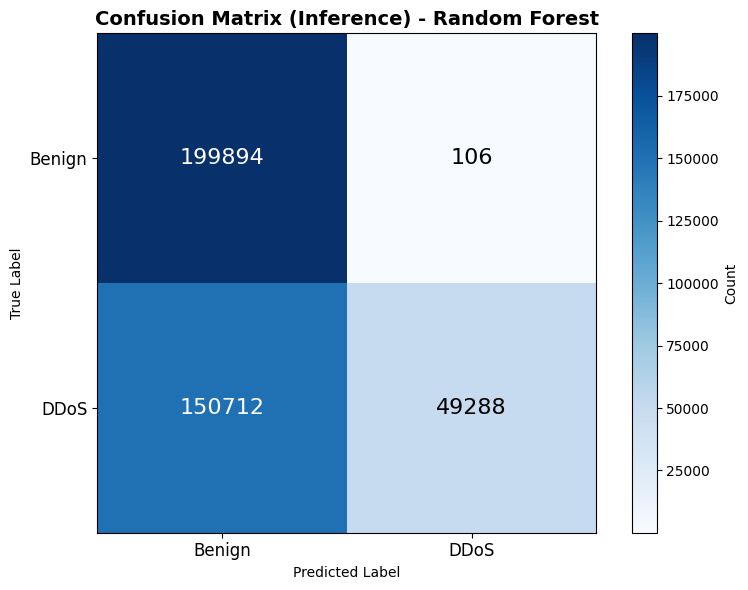

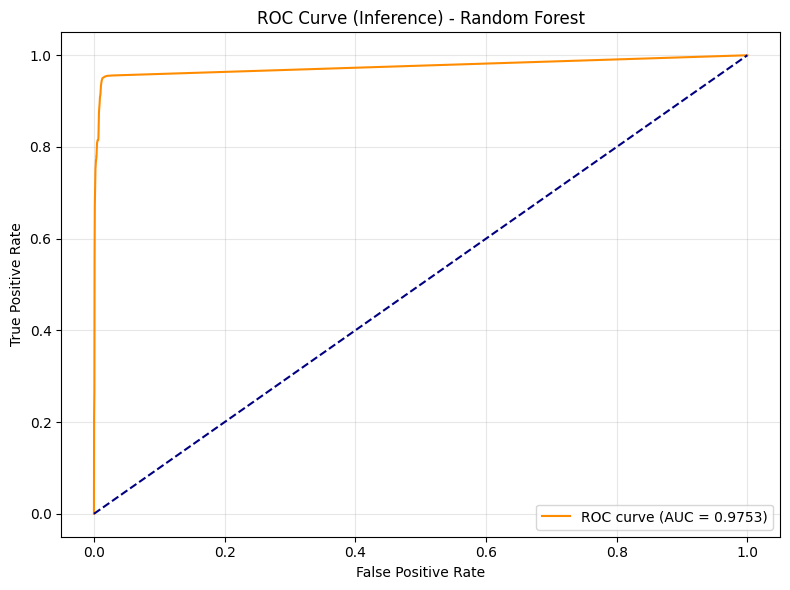

In [25]:
start_mem, start_cpu = get_usage()
start_wall = time.time()

MODEL_PATH = "../../data/models/rf_model.pkl"
IMPUTER_PATH = "../../data/models/rf_imputer.pkl"
DATA_PATH = "../../data/raw/unbalanced_dataset.csv"

rf = joblib.load(MODEL_PATH)
imputer = joblib.load(IMPUTER_PATH)
EXPECTED_PROTOCOLS = [0, 6, 17]
all_parts = []
counts = {}

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    for label, group in chunk.groupby("Label"):
        n = counts.get(label, 0)
        if n >= MAX_LABEL:
            continue

        group_shuffled = group.sample(frac=1, random_state=1)
        take = group_shuffled.iloc[: MAX_LABEL - n]
        all_parts.append(take)
        counts[label] = n + len(take)

    if len(counts) >= 2 and all(c >= MAX_LABEL for c in counts.values()):
        break

if not all_parts:
    print("uh oh")
else:
    # randomise data to avoid unintentional patterns
    df = pd.concat(all_parts, ignore_index=True)
    df = df.sample(frac=1, random_state=1).reset_index(drop=True)
    
    y_true = np.where(df["Label"].values == "ddos", 1, 0)
    df_features = df.copy()
    columns_to_drop = ["Label", "Unnamed: 0", "Flow ID", "Src IP", "Dst IP", "Timestamp", "Src Port", "Dst Port"]
    df_features = df_features.drop(columns=[c for c in columns_to_drop if c in df_features.columns])
    df_features["Protocol"] = pd.Categorical(df_features["Protocol"], categories=EXPECTED_PROTOCOLS)
    df_features = pd.get_dummies(df_features, columns=["Protocol"], prefix="Protocol")
    
    X = df_features.values.astype(np.float64)
    X = np.where(np.isinf(X), np.nan, X)
    
    try:
        X_imputed = imputer.transform(X)
        
        y_pred = rf.predict(X_imputed)
        y_proba = rf.predict_proba(X_imputed)[:, 1]
  
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation="nearest", cmap="Blues")
        plt.title("Confusion Matrix (Inference) - Random Forest", fontsize=14, fontweight="bold")
        plt.colorbar(label="Count")
        thresh = cm.max() / 2.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                         color="white" if cm[i, j] > thresh else "black", fontsize=16)
        plt.xticks(np.arange(2), ["Benign", "DDoS"], fontsize=12)
        plt.yticks(np.arange(2), ["Benign", "DDoS"], fontsize=12)
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.tight_layout()
        plt.savefig("../../plots/RF/inference_confusion_matrix.png", dpi=300, bbox_inches="tight")

        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color="darkorange", label=f"ROC curve (AUC = {roc_auc:.4f})")
        plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve (Inference) - Random Forest")
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig("../../plots/RF/inference_roc_curve.png", dpi=300, bbox_inches="tight")

        end_wall = time.time()
        end_mem, end_cpu = get_usage()
        pd.DataFrame([{
            "model": "RF_Inference",
            "ram_delta_mb": end_mem - start_mem,
            "cpu_time_sec": end_cpu - start_cpu,
            "wall_time_sec": end_wall - start_wall
        }]).to_csv("../../data/resource_usage.csv", mode='a', header=not os.path.exists("../../data/resource_usage.csv"), index=False)

        plt.show()

    except ValueError as e:
        print(e)
        raise e
